In [1]:
import numpy as np
import pandas as pd
np.random.seed(42)
n = 1000
household_size = np.random.randint(1, 8, n)
seasonal_index = np.round(np.random.uniform(0.7, 1.6, n), 2)
garden_area = np.random.randint(0, 120, n)
daily_liters_used = (
    40 +
    (household_size * 85) +
    (garden_area * 2.5) +
    (seasonal_index * 120) +
    np.random.normal(0, 50, n)   
)
daily_liters_used = np.round(daily_liters_used, 0)
df = pd.DataFrame({
    "Household_Size": household_size,
    "Seasonal_Index": seasonal_index,
    "Garden_Area": garden_area,
    "Daily_Liters_Used": daily_liters_used
})
for col in df.columns:
    random_rows = np.random.choice(df.index, 40, replace=False)
    df.loc[random_rows, col] = np.nan
duplicates = df.sample(50)
df = pd.concat([df, duplicates], ignore_index=True)
df.loc[np.random.choice(df.index, 20), "Daily_Liters_Used"] *= 3
df.loc[np.random.choice(df.index, 10), "Garden_Area"] = 500  
df["Seasonal_Index"] = df["Seasonal_Index"].astype("object")
df.loc[np.random.choice(df.index, 10), "Household_Size"] = -3
df.loc[np.random.choice(df.index, 10), "Seasonal_Index"] = "unknown"
df = df.sample(frac=1).reset_index(drop=True)
df.to_csv("updated_data.csv", index=False)
print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
   Household_Size Seasonal_Index  Garden_Area  Daily_Liters_Used
0             NaN            1.3         85.0                NaN
1             5.0        unknown         68.0              790.0
2             3.0           0.77         76.0              580.0
3             7.0           1.13        119.0             1108.0
4             1.0           1.39         73.0              492.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Household_Size     1008 non-null   float64
 1   Seasonal_Index     1008 non-null   object 
 2   Garden_Area        1008 non-null   float64
 3   Daily_Liters_Used  1010 non-null   float64
dtypes: float64(3), object(1)
memory usage: 32.9+ KB


In [3]:
print("Null Values in the dataset")
df.isna().sum()

Null Values in the dataset


Household_Size       42
Seasonal_Index       42
Garden_Area          42
Daily_Liters_Used    40
dtype: int64

In [4]:
df.describe()

,Household_Size,Garden_Area,Daily_Liters_Used
count,1008.000000,1008.000000,1010.000000
mean,3.897817,62.764881,692.379208
std,2.096120,56.222809,308.261804
min,-3.000000,0.000000,126.000000
25%,2.000000,27.000000,512.500000
50%,4.000000,59.000000,676.000000
75%,6.000000,90.000000,821.750000
max,7.000000,500.000000,3417.000000


In [5]:
print("Before Removing Duplicates in the Dataset")
df.shape

Before Removing Duplicates in the Dataset


(1050, 4)

In [6]:
df=df.drop_duplicates()

In [7]:
print("After removing duplicates")
df.shape

After removing duplicates


(1003, 4)

In [8]:
print("Information of Seasonal_Index column")
df["Seasonal_Index"].head(10)

Information of Seasonal_Index column


0        1.3
1    unknown
2       0.77
3       1.13
4       1.39
5       1.53
6       1.47
7       0.71
8       1.02
9       0.89
Name: Seasonal_Index, dtype: object

In [9]:
print("Unique values: \n")
df["Seasonal_Index"].unique()

Unique values: 



array([1.3, 'unknown', 0.77, 1.13, 1.39, 1.53, 1.47, 0.71, 1.02, 0.89,
       1.46, 0.74, 1.28, 0.72, 1.23, 1.34, 1.08, 0.81, 1.42, 1.11, 1.27,
       0.95, 1.48, 1.24, 0.97, 0.82, 0.92, 0.78, 1.17, 1.09, 1.58, 1.19,
       1.15, 1.0, 1.05, 0.85, 0.86, 0.99, 0.83, 1.31, 1.41, 0.73, 1.07,
       0.79, 1.36, 1.55, 1.18, 1.54, nan, 1.21, 1.44, 1.51, 1.5, 1.33,
       1.57, 0.8, 1.59, 1.25, 1.32, 1.49, 0.94, 0.96, 0.84, 1.43, 0.88,
       1.14, 0.76, 1.16, 1.06, 1.29, 1.04, 1.45, 0.93, 1.4, 1.35, 0.87,
       1.37, 1.1, 0.75, 1.26, 1.56, 0.91, 1.01, 0.98, 1.22, 1.2, 1.12,
       0.9, 1.03, 1.38, 1.52, 1.6, 0.7], dtype=object)

In [10]:
print("Value counts of Seasonal_Index")
df["Seasonal_Index"].value_counts()

Value counts of Seasonal_Index


Seasonal_Index
1.48    22
0.86    21
1.26    18
0.91    17
1.31    15
        ..
0.97     6
1.60     6
1.47     5
1.38     5
0.70     1
Name: count, Length: 92, dtype: int64

In [11]:
print(df["Seasonal_Index"].dtype)

object


In [12]:
print("Conerting the Seasonal_Index column to numeric datatype ")
df["Seasonal_Index"] = pd.to_numeric(df["Seasonal_Index"], errors="coerce")

Conerting the Seasonal_Index column to numeric datatype 


In [13]:
df["Seasonal_Index"].dtype
df["Seasonal_Index"].isnull().sum()

np.int64(50)

In [14]:
print("Filling missing values")
df["Seasonal_Index"].fillna(df["Seasonal_Index"].mean(), inplace=True)

Filling missing values


In [15]:
print("Checking unique values: ")
df["Household_Size"].unique()

Checking unique values: 


array([nan,  5.,  3.,  7.,  1.,  4.,  6.,  2., -3.])

In [16]:
df["Household_Size"].dtype

dtype('float64')

In [17]:
df.loc[df["Household_Size"] < 0, "Household_Size"] = np.nan

In [18]:
df["Household_Size"].fillna(df["Household_Size"].median(), inplace=True)

In [19]:
df["Household_Size"].isna().sum()

np.int64(0)

In [20]:
print("Unique values :")
df["Garden_Area"].unique()

Unique values :


array([ 85.,  68.,  76., 119.,  73.,  80.,  63.,  75.,  13.,  nan,  57.,
       111.,  50.,  98.,  24.,  21.,  42.,   4.,  34.,  97.,  69.,  22.,
        89.,  81.,  44.,  64.,  61., 116.,  31.,   3., 114., 108.,  20.,
         9.,  29.,  77.,  99.,  51.,  36.,  59.,  33.,  23., 500.,  91.,
       106.,  82., 115.,   8., 102., 100.,  79.,   0.,  10., 117.,  11.,
        49.,  88.,  72.,  15.,  41.,  92., 110.,  67.,  90.,  19., 105.,
       109.,  40.,  14.,   7., 103.,  62.,   1.,  86., 101., 104.,  37.,
        45.,  60.,  53.,   2., 112.,  87.,  54.,  25.,  26., 118.,  56.,
        17.,  55.,  27.,  30.,  16.,  70.,  52.,  39.,  94.,  93.,  35.,
         6.,  83.,  78.,  65.,  38.,  47.,  18., 113.,  84.,  43.,  12.,
        28.,   5.,  66.,  96.,  32.,  48.,  58.,  74.,  46., 107.,  95.,
        71.])

In [21]:
df["Garden_Area"].fillna(df["Garden_Area"].median(), inplace=True)

In [22]:
df["Daily_Liters_Used"].fillna(df["Daily_Liters_Used"].mean(), inplace=True)

In [23]:
#Outlier Detection using Z-Score
mean = df.mean()
std = df.std()
z_scores = (df - mean) / std
z_scores = z_scores.abs()
outlier_mask_z = z_scores > 3
print("Z-score outliers per column:\n", outlier_mask_z.sum())
print("Rows with Z-score outliers:", outlier_mask_z.any(axis=1).sum())
df[outlier_mask_z.any(axis=1)].head()

Z-score outliers per column:
 Household_Size        0
Seasonal_Index        0
Garden_Area          10
Daily_Liters_Used    14
dtype: int64
Rows with Z-score outliers: 24


,Household_Size,Seasonal_Index,Garden_Area,Daily_Liters_Used
55,5.0,1.31,500.0,718.0
72,6.0,1.50,64.0,2850.0
110,1.0,0.80,500.0,322.0
153,6.0,1.45,80.0,2757.0
210,4.0,0.91,100.0,2445.0


In [24]:
#Outlier Detection Using IQR
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outlier_mask_iqr = (df < lower_bound) | (df > upper_bound)
print("IQR outliers per column:\n", outlier_mask_iqr.sum())
print("Rows with IQR outliers:", outlier_mask_iqr.any(axis=1).sum())

IQR outliers per column:
 Household_Size        0
Seasonal_Index        0
Garden_Area          10
Daily_Liters_Used    17
dtype: int64
Rows with IQR outliers: 27


In [25]:
#Outlier Removal
df = df[~outlier_mask_iqr.any(axis=1)]

In [26]:
df.reset_index(drop=True, inplace=True)

In [27]:
#Feature Standardization
X = df.drop("Daily_Liters_Used", axis=1)
y = df["Daily_Liters_Used"]

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [30]:
#Model Training
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [31]:
household=int(input("Enter Household Size: "))
season=float(input("Enter Seasonal Index: "))
garden=int(input("Enter Garden Area: "))
input=pd.DataFrame([[household, season, garden]],
                          columns=["Household_Size", "Seasonal_Index", "Garden_Area"])
scaled=scaler.transform(input)
prediction=model.predict(scaled)
print("Predicted Daily Water Usage:", round(prediction[0], 2), "liters")

Enter Household Size:  2000
Enter Seasonal Index:  1.3
Enter Garden Area:  100


Predicted Daily Water Usage: 161372.02 liters


In [32]:
#Mean Absolute Error
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 49.591645949773714


In [33]:
#Mean Squared Error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 5033.023677956554


In [34]:
#RMSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 70.94380648059811


In [35]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("Mean Absolute Percentage Error:", mape, "%")

Mean Absolute Percentage Error: 8.662614837696088 %


In [36]:
residuals = y_test - y_pred
print("Sample Residuals:\n", residuals.head())
print("Mean of residuals:", residuals.mean())

Sample Residuals:
 199    10.575371
541    59.443140
174    53.245077
468     6.090607
66     26.260991
Name: Daily_Liters_Used, dtype: float64
Mean of residuals: -5.537832382499479


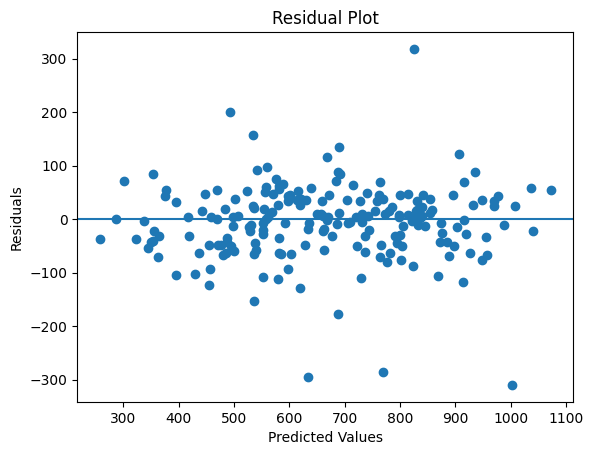

In [37]:
import matplotlib.pyplot as plt
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

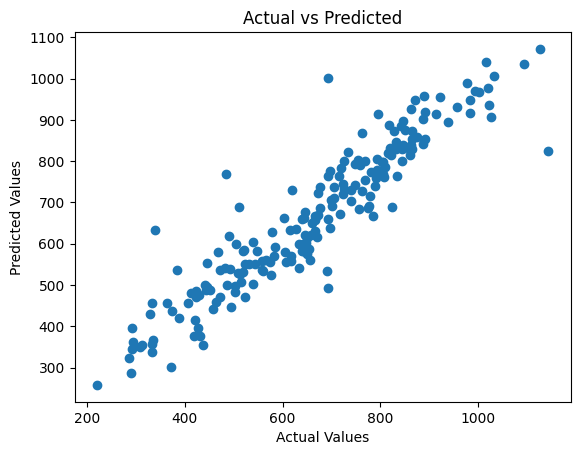

In [38]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

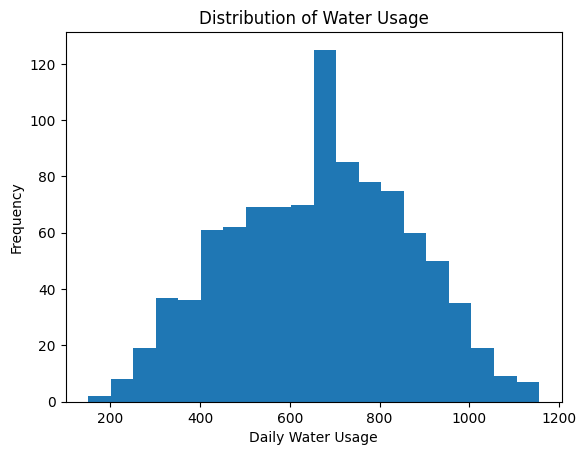

In [39]:
plt.hist(df["Daily_Liters_Used"], bins=20)
plt.xlabel("Daily Water Usage")
plt.ylabel("Frequency")
plt.title("Distribution of Water Usage")
plt.show()

In [40]:
df.to_csv("cleaned_urban_water_dataset.csv", index=False)